In [ ]:
import pandas as pd

df = pd.read_csv("weatherHistory.csv")

print(df.head())
print(df.info())

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0               1015.13  

In [ ]:
import numpy as np

df.drop_duplicates(inplace=True)

df.fillna(df.mean(numeric_only=True), inplace=True)

df["Heat_Index"] = df["Temperature (C)"] + (0.1 * df["Humidity"])

In [ ]:
import sqlite3

conn = sqlite3.connect("weather.db")

df.to_sql(
    "weather",
    conn,
    if_exists="replace",
    index=False
)

96429

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("weather.db")

# 1. Average Temperature
query = "SELECT AVG(\"Temperature (C)\") FROM weather;"
result_df = pd.read_sql_query(query, conn)
print(f"Average Temperature: {result_df.iloc[0,0]:.2f} C")

conn.close()

Average Temperature: 11.93 C


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("weather.db")

# 2. Maximum Humidity
query = "SELECT MAX(Humidity) FROM weather;"
result_df = pd.read_sql_query(query, conn)
print(f"Maximum Humidity: {result_df.iloc[0,0]:.2f}")

conn.close()

Maximum Humidity: 1.00


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("weather.db")

# 3. Minimum Temperature
query = "SELECT MIN(\"Temperature (C)\") FROM weather;"
result_df = pd.read_sql_query(query, conn)
print(f"Minimum Temperature: {result_df.iloc[0,0]:.2f} C")

conn.close()

Minimum Temperature: -21.82 C


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("weather.db")

# 4. Average Wind Speed
query = "SELECT AVG(\"Wind Speed (km/h)\") FROM weather;"
result_df = pd.read_sql_query(query, conn)
print(f"Average Wind Speed: {result_df.iloc[0,0]:.2f} km/h")

conn.close()

Average Wind Speed: 10.81 km/h


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("weather.db")

# 5. Top 5 Hottest Days
query = "SELECT \"Formatted Date\", \"Temperature (C)\", Summary FROM weather ORDER BY \"Temperature (C)\" DESC LIMIT 5;"
result_df = pd.read_sql_query(query, conn)
print("Top 5 Hottest Days:")
print(result_df)

conn.close()

Top 5 Hottest Days:
                  Formatted Date  Temperature (C)        Summary
0  2007-07-22 15:00:00.000 +0200        39.905556          Clear
1  2007-07-21 17:00:00.000 +0200        39.588889  Partly Cloudy
2  2007-07-19 16:00:00.000 +0200        38.983333  Partly Cloudy
3  2007-07-20 15:00:00.000 +0200        38.983333  Partly Cloudy
4  2007-07-20 16:00:00.000 +0200        38.983333  Partly Cloudy


In [ ]:
import matplotlib.pyplot as plt

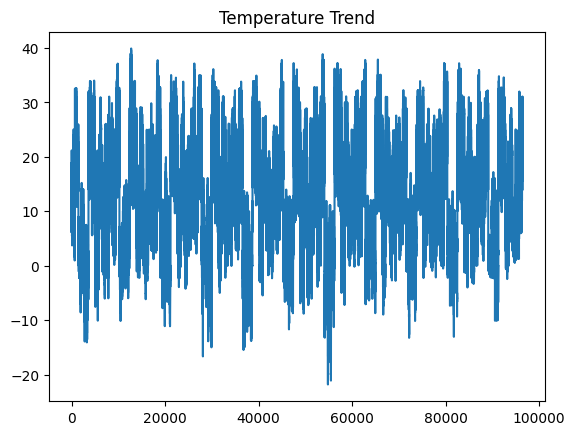

In [ ]:
plt.plot(df["Temperature (C)"])
plt.title("Temperature Trend")
plt.show()

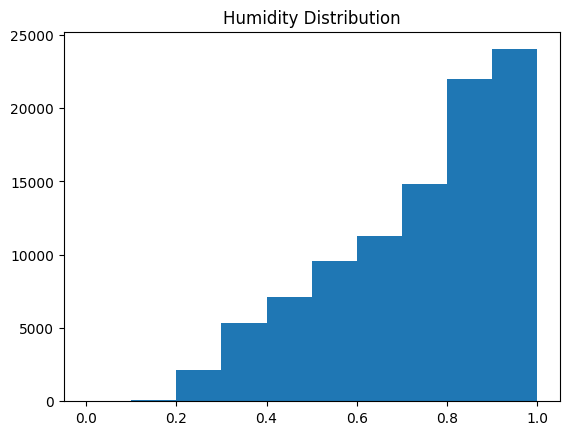

In [ ]:
plt.hist(df["Humidity"])
plt.title("Humidity Distribution")
plt.show()

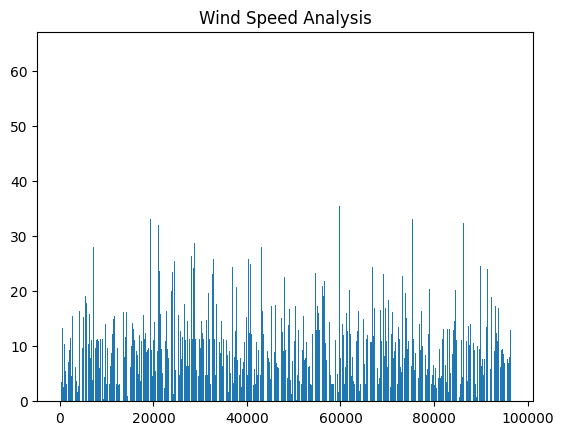

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Re-load and preprocess df to ensure it's defined
df = pd.read_csv("weatherHistory.csv")
df.drop_duplicates(inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)
df["Heat_Index"] = df["Temperature (C)"] + (0.1 * df["Humidity"])

plt.bar(range(len(df)), df["Wind Speed (km/h)"])
plt.title("Wind Speed Analysis")
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [6]:
X = df[["Temperature (C)", "Wind Speed (km/h)"]]
y = df["Humidity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print(prediction[:5])

[0.74438845 0.96093079 0.68770079 1.0458154  0.54380793]
